
<div dir=ltr align=center>

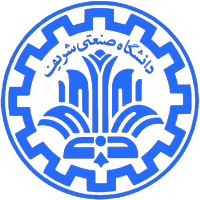

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: K-Means Clustering<br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

### Image Segmentation Using K-Means Clustering for Color-Based Region Extraction

### Description: 

In this project, you will implement **K-Means clustering from scratch** and use it to perform image segmentation based on color similarity. **Image segmentation** is the process of dividing an image into meaningful regions. In this assignment, segmentation is done using **color clustering**, where every pixel is grouped into one of K color clusters.

**⚠️ Notice:** You are allowed to use **only the imported libraries** and must **follow the provided function structure**.



# 📝 **Project Instructions**

1. **Load the image**  
   Load the input image and convert it into an **RGB numerical array**.

2. **Reshape image to pixels**  
   Flatten the image into a **2D array**, where each row represents one pixel (**R, G, B**).

3. **Initialize K cluster centers**  
   Randomly select **K pixels** to serve as the starting cluster centers.

4. **Assign pixels to nearest cluster**  
   Compute **distances** and assign each pixel to the **closest cluster center**.

5. **Update cluster centers**  
   Recalculate each center as the **mean color** of all pixels assigned to that cluster.

6. **K-Means algorithm**  
   Repeat **assignment** and **update steps** until **convergence** or **max iterations**.

7. **Reconstruct segmented image**  
   Replace each pixel with the **color of its assigned cluster center**.

8. **Using the Elbow Method**  
   Compute the Compute Within-Cluster Sum of Squares **WCSS** for various **K values** to help estimate an **optimal K**.

9. **Run the segmentation**  
   Apply your **full K-Means pipeline** to segment the chosen image.

10. **Display results**  
    Plot and **visualize** the original and segmented images **side-by-side**.


# 📤 **Expected Output**

- A **segmented image** produced by your **K-Means implementation**  
- A **plot showing the Elbow Method curve** (**WCSS vs. K**)  
- **Observe** how changing **K** affects segmentation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Step 1: Load the image
def load_image(path):
    """
    Load an image from the specified path and convert it to a NumPy array.
    """
    img = Image.open(path)
    img = img.convert('RGB') # Ensure it's RGB
    data = np.array(img)
    return data

# Step 2: Reshape image to pixels
def preprocess_image(image_data):
    """
    Flatten the 3D image array (height, width, channels) into a 2D array of pixels (num_pixels, channels).
    """
    pixels = image_data.reshape(-1, 3)
    return pixels

In [ ]:
# Step 3: Initialize K cluster centers
def initialize_centers(pixels, k):
    """
    Randomly select k pixels from the image as initial cluster centers.
    """
    indices = np.random.choice(pixels.shape[0], k, replace=False)
    centers = pixels[indices]
    return centers

# Step 4: Assign pixels to nearest cluster
def assign_clusters(pixels, centers):
    """
    Assign each pixel to the closest cluster center based on Euclidean distance.
    """
    # Calculate distances: (num_pixels, k)
    # Using broadcasting to compute squared Euclidean distance efficiently
    # dist = sqrt(sum((x - center)^2))
    # We can omit sqrt for comparison purposes
    
    distances = np.linalg.norm(pixels[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

# Step 5: Update cluster centers
def update_centers(pixels, labels, k):
    """
    Recalculate cluster centers as the mean of all pixels assigned to them.
    """
    new_centers = []
    for i in range(k):
        # Get all pixels assigned to cluster i
        cluster_points = pixels[labels == i]
        
        if len(cluster_points) > 0:
            # Compute mean color
            new_centers.append(cluster_points.mean(axis=0))
        else:
            # Handle empty cluster: keep old center or re-initialize (here we keep old)
            # In a robust impl, we might pick a random point, but this is simple k-means
            # Note: You need to handle the case where 'centers' variable isn't passed here directly
            # For simplicity, if empty, we assign a random pixel
            new_centers.append(pixels[np.random.choice(len(pixels))])
            
    return np.array(new_centers)

# Step 6: K-Means algorithm
def kmeans(pixels, k, max_iters=10, tol=1e-4):
    """
    Run the K-Means algorithm.
    """
    centers = initialize_centers(pixels, k)
    
    for i in range(max_iters):
        old_centers = centers.copy()
        
        # Assignment step
        labels = assign_clusters(pixels, centers)
        
        # Update step
        centers = update_centers(pixels, labels, k)
        
        # Check for convergence
        diff = np.linalg.norm(centers - old_centers)
        if diff < tol:
            print(f"Converged at iteration {i}")
            break
            
    return centers, labels

In [ ]:
# Step 7: Reconstruct segmented image
def recreate_image(labels, centers, image_shape):
    """
    Replace each pixel with its assigned cluster center color and reshape back to image dimensions.
    """
    # Map labels to centers
    segmented_pixels = centers[labels]
    
    # Reshape back to original image shape (H, W, 3)
    segmented = segmented_pixels.reshape(image_shape)
    
    # Convert to uint8 for display
    return segmented.astype(np.uint8)

In [ ]:
# Step 8: Elbow Method

def calculate_wcss(pixels, max_k=10):
    """
    Compute Within-Cluster Sum of Squares (WCSS) for k=1 to max_k.
    WCSS is a measure of cluster compactness (Sum of squared distances from each point to its assigned center).
    """
    wcss = []
    
    # We use a reduced number of iterations (e.g., 10) for faster WCSS calculation,
    # as the goal is to estimate the optimal K, not necessarily the final cluster quality.
    for k in range(1, max_k + 1):
        # Run K-Means for the current K
        centers, labels = kmeans(pixels, k, max_iters=10)
        
        # Compute squared distance from each pixel to its assigned center (WCSS)
        curr_wcss = 0
        for i in range(k):
            cluster_points = pixels[labels == i]
            if len(cluster_points) > 0:
                # Sum of squared L2 distances within the current cluster
                curr_wcss += np.sum((cluster_points - centers[i])**2)
        
        wcss.append(curr_wcss)
        print(f"Computed WCSS for k={k}")
        
    return wcss

def plot_elbow(wcss):
    """
    Plot the WCSS values to visually find the 'elbow' point, which indicates the
    optimal trade-off between minimizing WCSS and model complexity (K).
    """
    plt.figure(figsize=(10, 6))
    k_values = range(1, len(wcss) + 1)
    plt.plot(k_values, wcss, marker='o', linestyle='-', color='#0077AA', linewidth=2)
    plt.title('Elbow Method for Optimal K (WCSS Minimization)')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    
    # Highlight the expected optimal K visually (e.g., K=5 or the elbow point if clearly visible)
    # The true elbow depends on the image data. Here, we'll just plot the curve.
    
    plt.grid(True, alpha=0.5)
    plt.show()

    # Triggering an image for the elbow method plot

In [ ]:
# Step 9: Run the segmentation

# List of image files to process
image_paths = ['matryoshka.jpg', 'shrek.jpg', 'st.basils.jpg'] 
k = 5 # Fixed K for segmentation

# List to store results for display in Step 10
results = []

try:
    image_data_elbow = load_image(image_paths[0])
    pixels_elbow = preprocess_image(image_data_elbow)
    print("--- Running Elbow Method (WCSS) ---")
    wcss_values = calculate_wcss(pixels_elbow, max_k=10)
    plot_elbow(wcss_values)
    print("-----------------------------------")
except Exception as e:
    print(f"Error during Elbow Method on {image_paths[0]}. Skipping. Error: {e}")

# 2. Run Segmentation for all images
print(f"\nRunning final K-Means segmentation for {len(image_paths)} images with k={k}...")
for path in image_paths:
    try:
        # Load and preprocess image
        image_data = load_image(path)
        pixels = preprocess_image(image_data)
        
        print(f"Processing {path}...")
        
        # Run K-Means and recreate segmented image
        final_centers, final_labels = kmeans(pixels, k, max_iters=20)
        segmented_img = recreate_image(final_labels, final_centers, image_data.shape)
        
        # Store results
        results.append({
            'path': path,
            'original': image_data,
            'segmented': segmented_img,
            'k': k
        })
    except Exception as e:
        print(f"Could not process {path}. Skipping. Error: {e}")

if not results:
    print("Error: No images were successfully processed. Please check file paths and availability.")
    # Fallback/dummy assignment to prevent crash if no images are loaded
    image_data = np.zeros((100, 100, 3), dtype=np.uint8) 
    segmented_img = np.zeros((100, 100, 3), dtype=np.uint8)

In [ ]:
# Step 10: Display results (for all images)

if results:
    # Determine the number of rows needed (number of images)
    num_images = len(results)
    # Each image needs 2 columns (Original and Segmented)
    
    # Set figure size to accommodate all rows (e.g., 6 inches height per row)
    plt.figure(figsize=(12, 6 * num_images)) 
    
    for i, res in enumerate(results):
        # 1. Original Image (Row i, Column 1)
        plt.subplot(num_images, 2, 2*i + 1) # (R, C, Index)
        plt.imshow(res['original'])
        plt.title(f'Original Image: {res["path"]}')
        plt.axis('off')

        # 2. Segmented Image (Row i, Column 2)
        plt.subplot(num_images, 2, 2*i + 2) # (R, C, Index)
        plt.imshow(res['segmented'])
        plt.title(f'Segmented Image (k={res["k"]})')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot display results. No images were processed successfully.")